# Time Series Forecasting of Airline Passenger Traffic
### A Beginner-Level ARIMA & SARIMA Project

**Dataset:** Monthly totals of international airline passengers (1949–1960), in thousands.

**Project workflow:**
1. Load data and handle missing values (linear interpolation)
2. Exploratory Data Analysis (EDA)
3. Multiplicative time series decomposition
4. Stationarity check with the Augmented Dickey-Fuller (ADF) test
5. Differencing to remove trend and seasonality
6. ACF / PACF plots to identify model order
7. Train-test split
8. Fit ARIMA models
9. Fit SARIMA models
10. Evaluate models using RMSE, MAPE, AIC, BIC
11. Validate residuals (independence & normality)
12. Pick the best model
13. Improve the best model further

This project intentionally stops at the SARIMA level and does not use more advanced techniques (e.g. auto_arima, Prophet, or deep learning models), keeping it beginner-friendly.

## 1. Importing Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Loading the Data

The CSV file has no header. The first column is the month (`YYYY-MM`) and the second column is
the number of passengers (in thousands).

In [2]:
data = pd.read_csv("airline-passenger-traffic.csv", header=None, names=["Month", "Passengers"])
print("Shape:", data.shape)
data.head()

Shape: (144, 2)


,Month,Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [3]:
data["Month"] = pd.to_datetime(data["Month"], format="%Y-%m")
data.set_index("Month", inplace=True)
data.index.freq = "MS"  # Monthly Start frequency
data.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [4]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Passengers  140 non-null    float64
dtypes: float64(1)
memory usage: 2.2 KB


,Passengers
count,140.000000
mean,280.735714
std,120.593235
min,104.000000
25%,180.000000
50%,268.000000
75%,360.500000
max,622.000000


## 3. Handling Missing Values

Let's first check how many missing values are present, and where they occur.

In [5]:
missing = data[data["Passengers"].isnull()]
print("Number of missing values:", data["Passengers"].isnull().sum())
missing

Number of missing values: 4


,Passengers
Month,
1951-06-01,NaN
1951-07-01,NaN
1954-06-01,NaN
1960-03-01,NaN


### Linear Interpolation

We use **linear interpolation** to fill the missing values. Linear interpolation estimates a
missing value by drawing a straight line between the nearest known values before and after the
gap, which works well for a smoothly trending/seasonal series like this one, and is simple enough
for a beginner-level project (compared to, say, seasonal or model-based imputation).

In [6]:
data["Passengers"] = data["Passengers"].interpolate(method="linear")
print("Remaining missing values:", data["Passengers"].isnull().sum())
data.loc[missing.index]

Remaining missing values: 0


,Passengers
Month,
1951-06-01,181.0
1951-07-01,190.0
1954-06-01,268.0
1960-03-01,426.0


## 4. Exploratory Data Analysis (EDA)

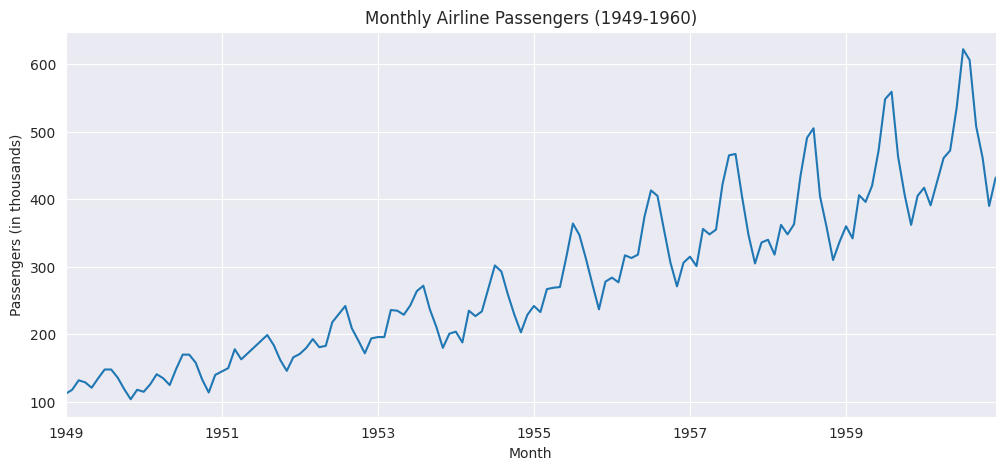

In [7]:
data["Passengers"].plot(title="Monthly Airline Passengers (1949-1960)")
plt.xlabel("Month")
plt.ylabel("Passengers (in thousands)")
plt.show()

Observations:
- There is a clear **upward trend** in passenger numbers over the years.
- There is a repeating **yearly seasonal pattern** (peaks around mid-year, likely summer travel).
- The size of the seasonal swings **grows** as the overall level grows — a sign of **multiplicative**
  seasonality rather than additive.

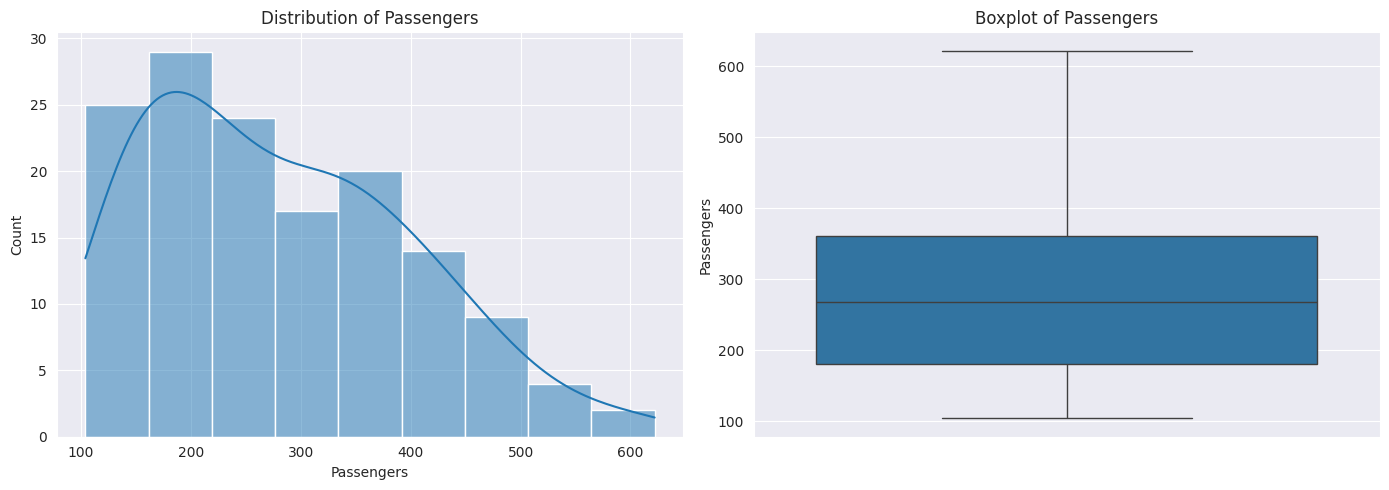

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data["Passengers"], kde=True, ax=ax[0])
ax[0].set_title("Distribution of Passengers")
sns.boxplot(y=data["Passengers"], ax=ax[1])
ax[1].set_title("Boxplot of Passengers")
plt.tight_layout()
plt.show()

## 5. Time Series Decomposition (Multiplicative)

Since the seasonal fluctuations grow with the trend, we decompose the series using a
**multiplicative model**:

$$ Y_t = Trend_t \times Seasonal_t \times Residual_t $$

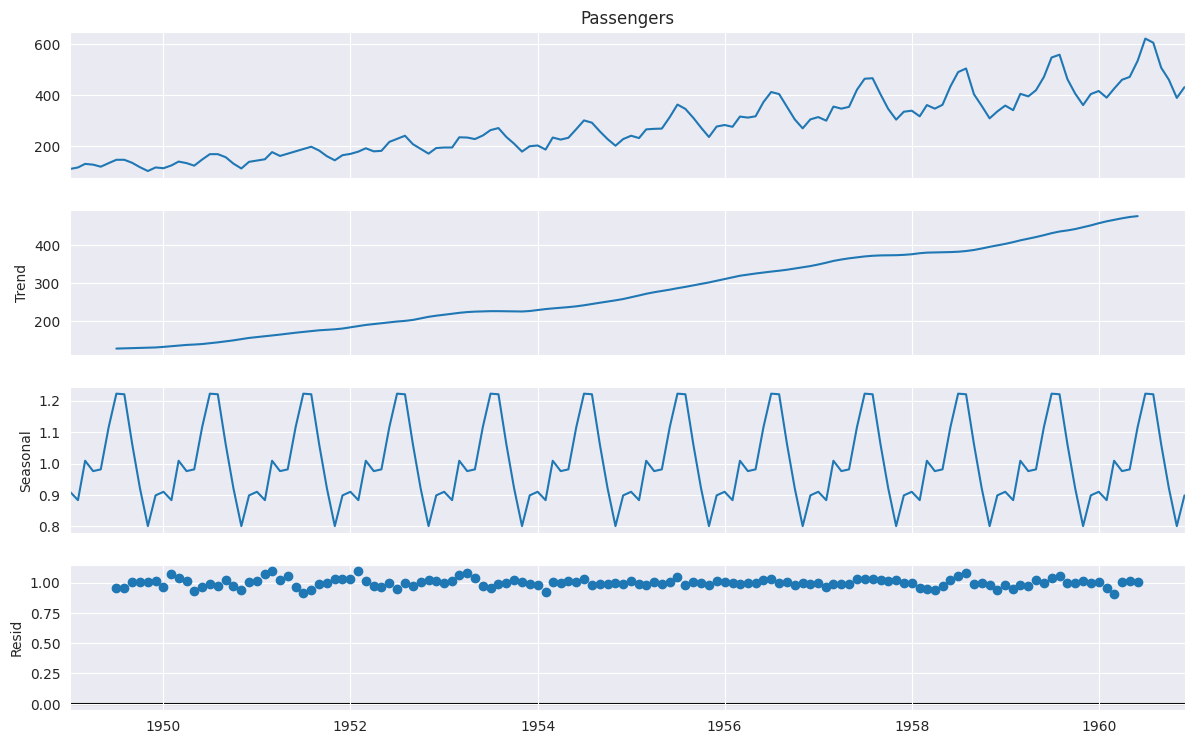

In [9]:
decomposition = sm.tsa.seasonal_decompose(data["Passengers"], model="multiplicative")
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

The decomposition confirms:
- A clear **upward trend** throughout the period.
- A stable **12-month seasonal cycle** that repeats every year.
- Residuals that fluctuate around 1 (as expected for a multiplicative model) without an obvious pattern.

## 6. Checking Stationarity

Most ARIMA-family models require the series to be (approximately) **stationary** — i.e. its mean,
variance and autocorrelation structure should not change over time.

### Augmented Dickey-Fuller (ADF) Test

- **H0:** The series has a unit root (it is **non-stationary**).
- **H1:** The series does **not** have a unit root (it is **stationary**).

If the p-value is below 0.05, we reject H0 and conclude the series is stationary.

In [10]:
def adf_report(series, title):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {title} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] <= 0.05:
        print("=> Reject H0: The series is stationary.\n")
    else:
        print("=> Fail to reject H0: The series is non-stationary.\n")

adf_report(data["Passengers"], "Original Series")

--- ADF Test: Original Series ---
ADF Statistic : 0.8946
p-value       : 0.9930
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788
=> Fail to reject H0: The series is non-stationary.



The p-value is well above 0.05, so the original series is **non-stationary** — as expected,
since we can visually see a trend and seasonality.

## 7. Differencing

We apply differencing to remove the trend and seasonality so the series becomes stationary.

### First-order (regular) differencing

Subtracting each observation from the previous one removes a linear trend:

$$ Y'_t = Y_t - Y_{t-1} $$

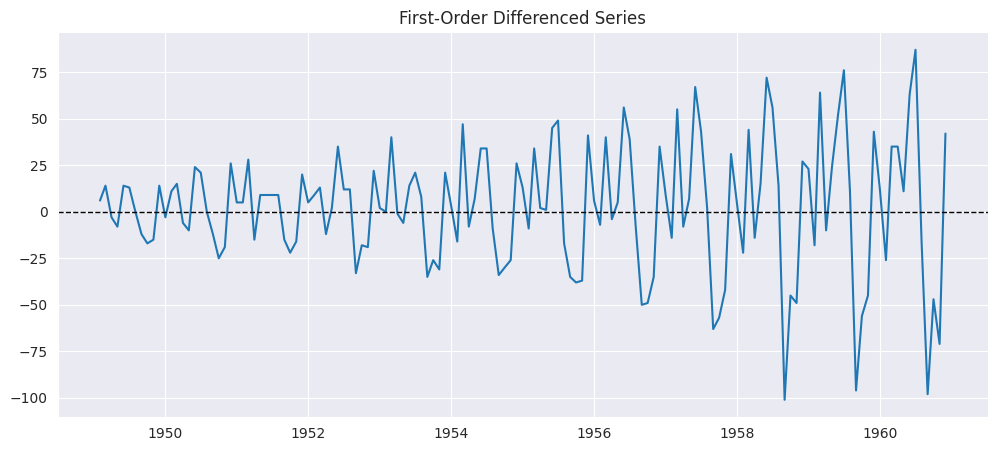

--- ADF Test: First-Order Differenced Series ---
ADF Statistic : -2.9036
p-value       : 0.0449
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788
=> Reject H0: The series is stationary.



In [11]:
diff_1 = data["Passengers"].diff().dropna()

plt.plot(diff_1)
plt.title("First-Order Differenced Series")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.show()

adf_report(diff_1, "First-Order Differenced Series")

The mean is now roughly constant around zero and the ADF test's p-value drops below 0.05,
so the trend has been removed. However, the swings still get wider over time and a repeating
12-month pattern is visible — the **seasonality** is still present.

### Seasonal differencing (lag = 12)

We additionally apply a seasonal difference at lag 12 (subtracting the value from 12 months earlier)
on top of the first-order difference to remove the yearly seasonal pattern.

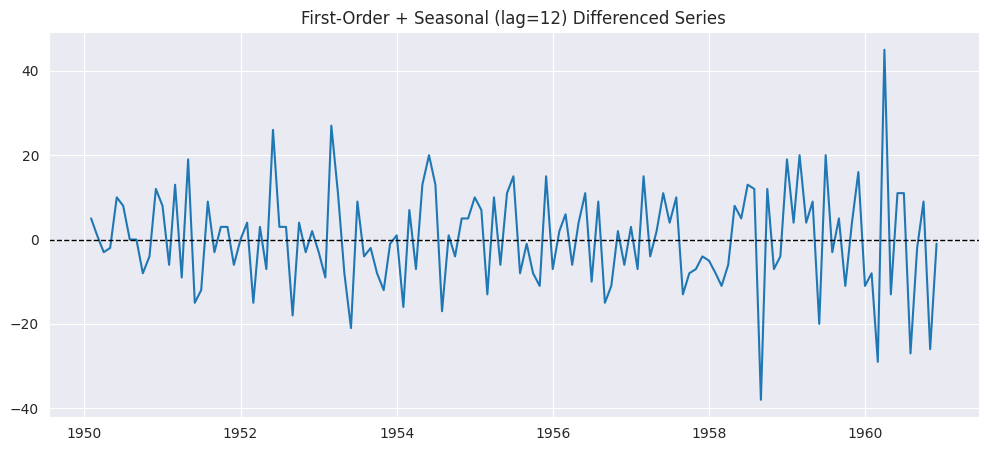

--- ADF Test: First-Order + Seasonal Differenced Series ---
ADF Statistic : -14.6860
p-value       : 0.0000
Critical Values:
   1%: -3.4817
   5%: -2.8840
   10%: -2.5788
=> Reject H0: The series is stationary.



In [12]:
seasonal_diff = diff_1.diff(12).dropna()

plt.plot(seasonal_diff)
plt.title("First-Order + Seasonal (lag=12) Differenced Series")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.show()

adf_report(seasonal_diff, "First-Order + Seasonal Differenced Series")

After combining regular differencing (`d=1`) with seasonal differencing (`D=1`, `s=12`), the
series has a constant mean, roughly constant variance, and the ADF test strongly rejects the
null hypothesis (very small p-value). This differenced series will guide our choice of `d` and `D`
for ARIMA/SARIMA.

## 8. ACF and PACF Plots

We use the doubly-differenced series above to inspect the **Autocorrelation Function (ACF)** and
**Partial Autocorrelation Function (PACF)** plots, which help us guess reasonable starting values
for the AR and MA orders:

- **PACF** cutting off after lag *p* → suggests an AR(*p*) term.
- **ACF** cutting off after lag *q* → suggests an MA(*q*) term.
- Spikes at seasonal lags (12, 24, ...) suggest seasonal AR/MA terms (`P`, `Q`).

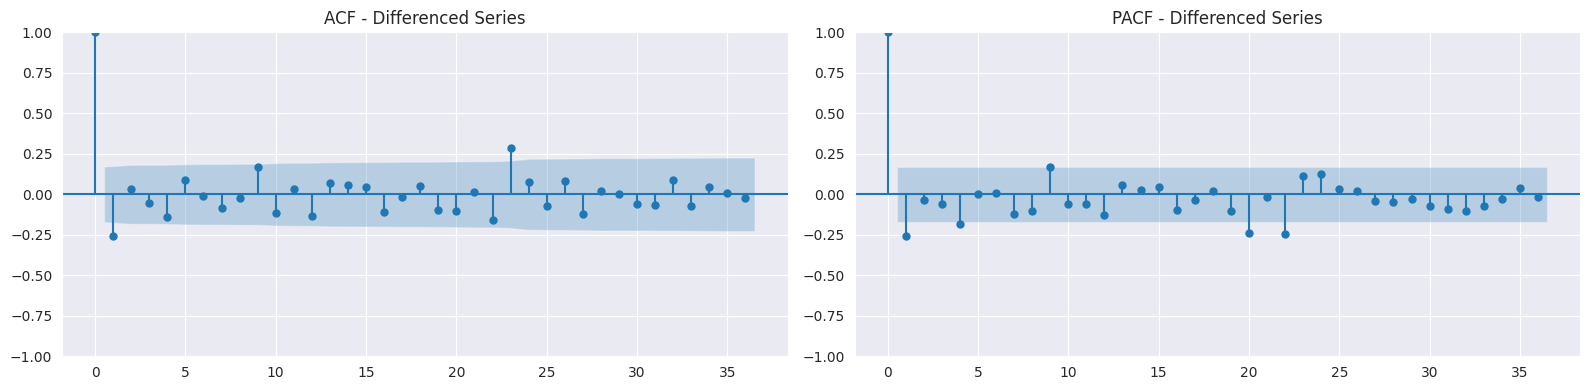

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(seasonal_diff, ax=ax[0], lags=36)
ax[0].set_title("ACF - Differenced Series")
plot_pacf(seasonal_diff, ax=ax[1], lags=36)
ax[1].set_title("PACF - Differenced Series")
plt.tight_layout()
plt.show()

Reading the plots:
- The ACF shows a significant spike at lag 1 and small spikes around the seasonal lags (12, 24),
  suggesting a small MA term and a seasonal MA component.
- The PACF shows significant spikes at low lags (1-2) and around lag 12, suggesting a small AR
  term and a seasonal AR component.

Based on this, we will try small values of `p`, `q`, `P`, `Q` (0–2) with `d=1` and `D=1`,
`s=12`, and let AIC/BIC and out-of-sample error pick the best combination — rather than
committing to a single value by eye.

## 9. Train-Test Split

Since the seasonal swings grow with the level of the series (multiplicative behaviour), we take a
**log transform** first. This stabilizes the variance and turns the multiplicative seasonality
into an additive one, which is what ARIMA/SARIMA models assume. All forecasts will later be
converted back to the original scale using `exp()`.

We hold out the **last 24 months (2 years)** as the test set, and use the rest for training.

Train size: 120  (1949-01-01 to 1958-12-01)
Test size : 24  (1959-01-01 to 1960-12-01)


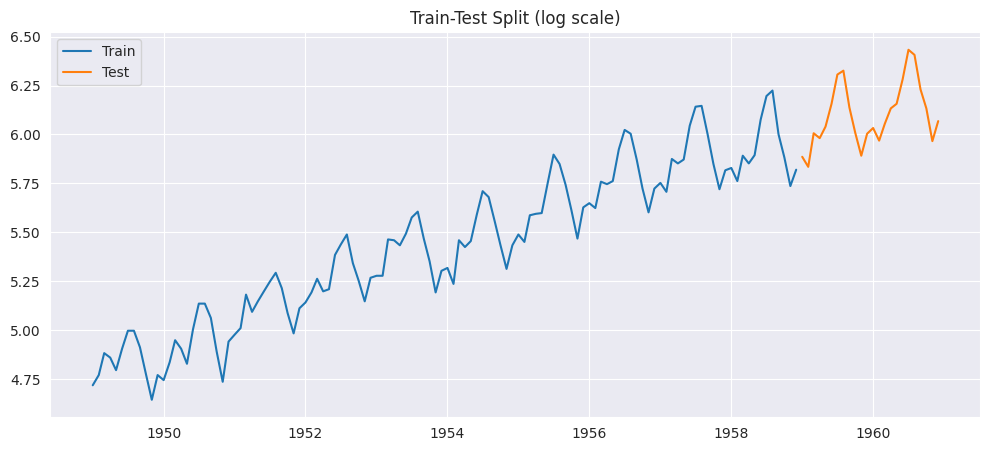

In [14]:
log_data = np.log(data["Passengers"])

train = log_data.iloc[:-24]
test = log_data.iloc[-24:]

print(f"Train size: {len(train)}  ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test size : {len(test)}  ({test.index.min().date()} to {test.index.max().date()})")

plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Train-Test Split (log scale)")
plt.legend()
plt.show()

## 10. ARIMA Modeling

We first fit plain **ARIMA(p, d, q)** models (no seasonal component) as a baseline, trying a
small set of candidate orders around what the ACF/PACF plots suggested, and pick the one with
the lowest **AIC**.

In [15]:
arima_orders = [(1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2), (0, 1, 1), (1, 1, 0)]

arima_results = []
for order in arima_orders:
    try:
        model = ARIMA(train, order=order).fit()
        arima_results.append({"order": order, "AIC": model.aic, "BIC": model.bic})
    except Exception as e:
        print(f"Order {order} failed: {e}")

arima_results_df = pd.DataFrame(arima_results).sort_values("AIC").reset_index(drop=True)
arima_results_df

,order,AIC,BIC
0,"(2, 1, 1)",-208.904292,-197.787798
1,"(1, 1, 2)",-207.989754,-196.873260
2,"(2, 1, 2)",-206.862549,-192.966931
3,"(1, 1, 1)",-202.662686,-194.325316
4,"(0, 1, 1)",-199.611364,-194.053117
5,"(1, 1, 0)",-197.774500,-192.216253


In [16]:
best_arima_order = arima_results_df.loc[0, "order"]
print("Best ARIMA order (by AIC):", best_arima_order)

arima_model = ARIMA(train, order=best_arima_order).fit()
print(arima_model.summary())

Best ARIMA order (by AIC): (2, 1, 1)
                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  120
Model:                 ARIMA(2, 1, 1)   Log Likelihood                 108.452
Date:                Fri, 21 Aug 2026   AIC                           -208.904
Time:                        07:10:19   BIC                           -197.788
Sample:                    01-01-1949   HQIC                          -204.390
                         - 12-01-1958                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9551      0.111      8.585      0.000       0.737       1.173
ar.L2         -0.3615      0.126     -2.861      0.004      -0.609      -0.114
ma.L1         -

ARIMA(2, 1, 1)  ->  RMSE: 107.99   MAPE: 16.33%
AIC: -208.90   BIC: -197.79


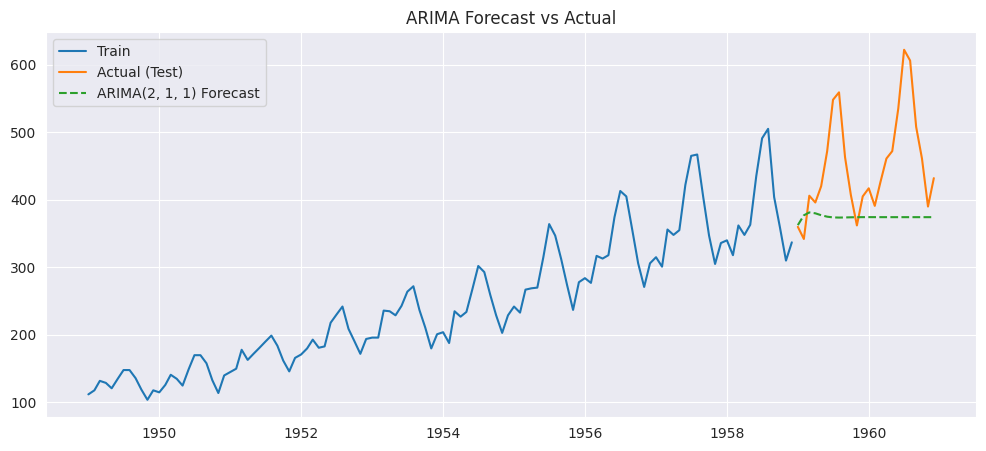

In [17]:
arima_forecast = arima_model.get_forecast(steps=len(test))
arima_pred_log = arima_forecast.predicted_mean

# back-transform to the original scale
arima_pred = np.exp(arima_pred_log)
actual = np.exp(test)

arima_rmse = np.sqrt(mean_squared_error(actual, arima_pred))
arima_mape = mean_absolute_percentage_error(actual, arima_pred) * 100

print(f"ARIMA{best_arima_order}  ->  RMSE: {arima_rmse:.2f}   MAPE: {arima_mape:.2f}%")
print(f"AIC: {arima_model.aic:.2f}   BIC: {arima_model.bic:.2f}")

plt.plot(np.exp(train), label="Train")
plt.plot(actual, label="Actual (Test)")
plt.plot(arima_pred, label=f"ARIMA{best_arima_order} Forecast", linestyle="--")
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.show()

The plain ARIMA model captures the overall upward trend reasonably well, but since it has no
seasonal term, it **cannot reproduce the yearly seasonal pattern** in the test period. This is
exactly the gap that SARIMA is designed to fill.

## 11. SARIMA Modeling

**SARIMA(p, d, q)(P, D, Q, s)** extends ARIMA with a seasonal component. Based on the ACF/PACF
plots and the differencing we performed (`d=1`, `D=1`, `s=12`), we search over a small grid of
`p, q, P, Q` values (0–2) and select the combination with the lowest AIC.

In [18]:
import itertools

p = q = range(0, 3)
P = Q = range(0, 2)
d, D, s = 1, 1, 12

sarima_results = []
for order in itertools.product(p, [d], q):
    for seasonal in itertools.product(P, [D], Q):
        seasonal_order = seasonal + (s,)
        try:
            model = SARIMAX(
                train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
            sarima_results.append({
                "order": order, "seasonal_order": seasonal_order,
                "AIC": model.aic, "BIC": model.bic
            })
        except Exception:
            continue

sarima_results_df = pd.DataFrame(sarima_results).sort_values("AIC").reset_index(drop=True)
sarima_results_df.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC
0,"(1, 1, 0)","(0, 1, 0, 12)",-356.439513,-351.112635
1,"(1, 1, 1)","(0, 1, 0, 12)",-354.427073,-346.465192
2,"(0, 1, 1)","(0, 1, 0, 12)",-353.994078,-348.686157
3,"(2, 1, 1)","(0, 1, 0, 12)",-353.330434,-342.714593
4,"(0, 1, 0)","(0, 1, 0, 12)",-352.494144,-349.830705
5,"(2, 1, 0)","(0, 1, 0, 12)",-351.150024,-343.188143
6,"(1, 1, 2)","(0, 1, 0, 12)",-349.862615,-339.285052
7,"(0, 1, 2)","(0, 1, 0, 12)",-349.350341,-341.417168
8,"(2, 1, 2)","(0, 1, 0, 12)",-347.995918,-334.773964
9,"(0, 1, 1)","(1, 1, 0, 12)",-341.819994,-334.158364


In [19]:
best_sarima_order = sarima_results_df.loc[0, "order"]
best_sarima_seasonal_order = sarima_results_df.loc[0, "seasonal_order"]
print("Best SARIMA order (by AIC):", best_sarima_order, best_sarima_seasonal_order)

sarima_model = SARIMAX(
    train, order=best_sarima_order, seasonal_order=best_sarima_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)
print(sarima_model.summary())

Best SARIMA order (by AIC): (1, 1, 0) (0, 1, 0, 12)
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 12)   Log Likelihood                 180.220
Date:                            Fri, 21 Aug 2026   AIC                           -356.440
Time:                                    07:10:25   BIC                           -351.113
Sample:                                01-01-1949   HQIC                          -354.281
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2328      0.071     -3.299      0.001      -0

SARIMA(1, 1, 0)x(0, 1, 0, 12)  ->  RMSE: 73.92   MAPE: 14.89%
AIC: -356.44   BIC: -351.11


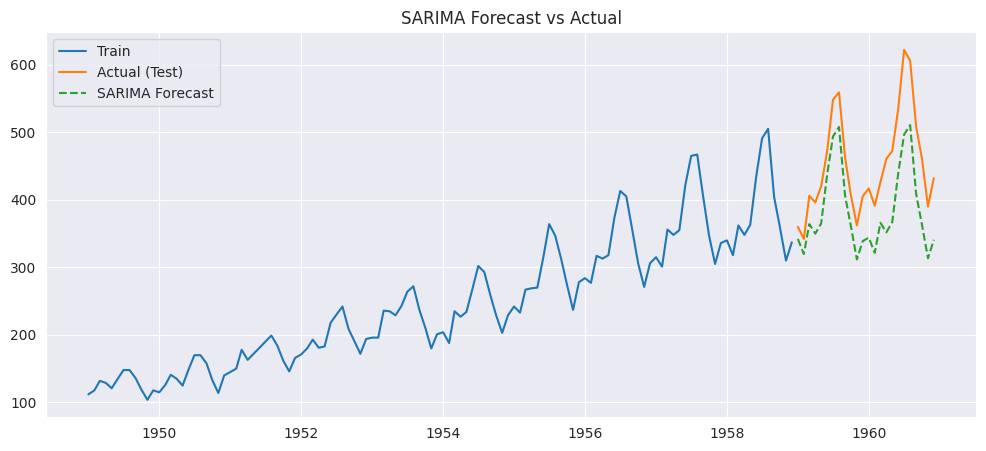

In [20]:
sarima_forecast = sarima_model.get_forecast(steps=len(test))
sarima_pred_log = sarima_forecast.predicted_mean
sarima_pred = np.exp(sarima_pred_log)

sarima_rmse = np.sqrt(mean_squared_error(actual, sarima_pred))
sarima_mape = mean_absolute_percentage_error(actual, sarima_pred) * 100

print(f"SARIMA{best_sarima_order}x{best_sarima_seasonal_order}  ->  RMSE: {sarima_rmse:.2f}   MAPE: {sarima_mape:.2f}%")
print(f"AIC: {sarima_model.aic:.2f}   BIC: {sarima_model.bic:.2f}")

plt.plot(np.exp(train), label="Train")
plt.plot(actual, label="Actual (Test)")
plt.plot(sarima_pred, label=f"SARIMA Forecast", linestyle="--")
plt.title("SARIMA Forecast vs Actual")
plt.legend()
plt.show()

SARIMA's forecast tracks the seasonal ups and downs of the test period much more closely than plain ARIMA, since it explicitly models the 12-month seasonal pattern.

## 12. Model Comparison

Let's put ARIMA and SARIMA side by side using **RMSE**, **MAPE**, **AIC** and **BIC**.

- **RMSE** and **MAPE** measure out-of-sample forecast accuracy (lower is better).
- **AIC** and **BIC** measure in-sample model fit while penalizing complexity (lower is better).

In [21]:
comparison = pd.DataFrame({
    "Model": [f"ARIMA{best_arima_order}", f"SARIMA{best_sarima_order}x{best_sarima_seasonal_order}"],
    "RMSE": [arima_rmse, sarima_rmse],
    "MAPE (%)": [arima_mape, sarima_mape],
    "AIC": [arima_model.aic, sarima_model.aic],
    "BIC": [arima_model.bic, sarima_model.bic],
})
comparison

,Model,RMSE,MAPE (%),AIC,BIC
0,"ARIMA(2, 1, 1)",107.985896,16.326866,-208.904292,-197.787798
1,"SARIMA(1, 1, 0)x(0, 1, 0, 12)",73.916471,14.894221,-356.439513,-351.112635


In [22]:
best_model_name = comparison.loc[comparison["RMSE"].idxmin(), "Model"]
print(f"Best model based on out-of-sample RMSE: {best_model_name}")

Best model based on out-of-sample RMSE: SARIMA(1, 1, 0)x(0, 1, 0, 12)


**SARIMA clearly outperforms plain ARIMA** on every metric — lower RMSE, lower MAPE, and lower
AIC/BIC. This matches what we already saw visually: this dataset has strong, regular seasonality
that only SARIMA's seasonal terms can capture. We proceed with **SARIMA as our best model**.

## 13. Residual Diagnostics for the Best Model (SARIMA)

A good model's residuals should behave like white noise: **independent** (no leftover
autocorrelation) and (ideally) **normally distributed** around zero.

We drop the first few residuals affected by the model's start-up/initialization period
(`loglikelihood_burn`) before running the diagnostics, since these are not meaningful residuals.

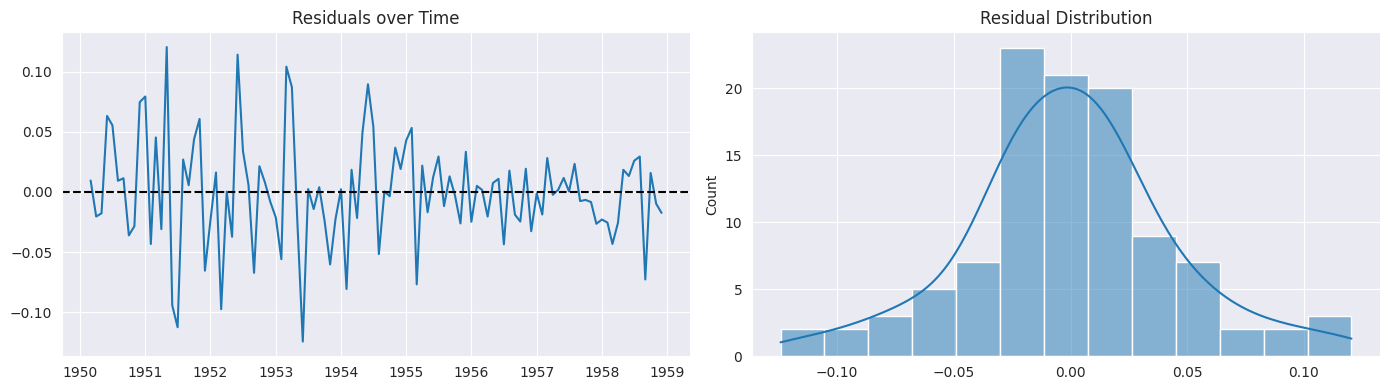

In [23]:
residuals = sarima_model.resid[sarima_model.loglikelihood_burn:]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(residuals)
ax[0].axhline(0, color="black", linestyle="--")
ax[0].set_title("Residuals over Time")
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

### Independence — Ljung-Box Test

- **H0:** Residuals are independently distributed (no autocorrelation).
- **H1:** Residuals are not independent (autocorrelation is present).

A p-value above 0.05 means we fail to reject H0, i.e. residuals appear independent.

In [24]:
lb_test = acorr_ljungbox(residuals, lags=[6, 12, 18], return_df=True)
lb_test

,lb_stat,lb_pvalue
6,8.020819,0.236582
12,40.074781,0.000070
18,45.864039,0.000311


### ACF plot of residuals (visual check for independence)

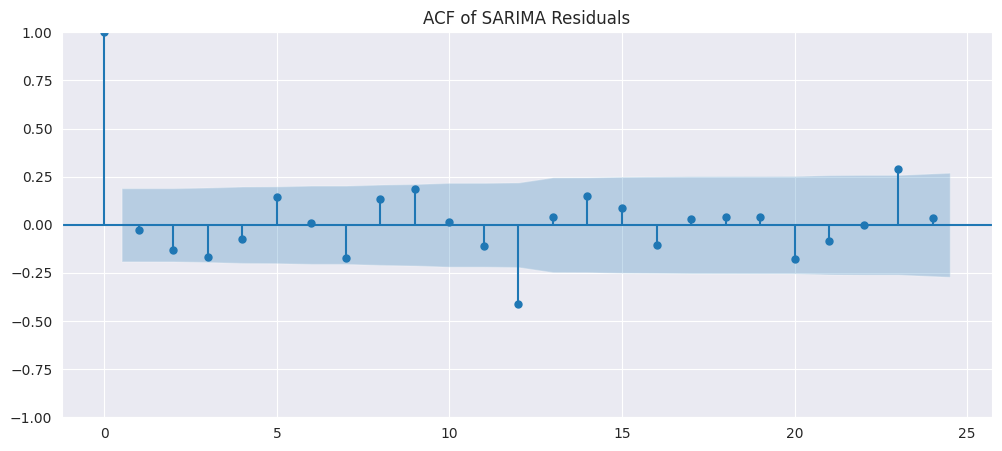

In [25]:
plot_acf(residuals, lags=24)
plt.title("ACF of SARIMA Residuals")
plt.show()

### Normality — Shapiro-Wilk Test

- **H0:** The residuals are normally distributed.
- **H1:** The residuals are not normally distributed.

A p-value above 0.05 means we fail to reject H0, i.e. residuals appear normally distributed.

Shapiro-Wilk Statistic: 0.9794
p-value: 0.0980
=> Fail to reject H0: residuals appear normally distributed.


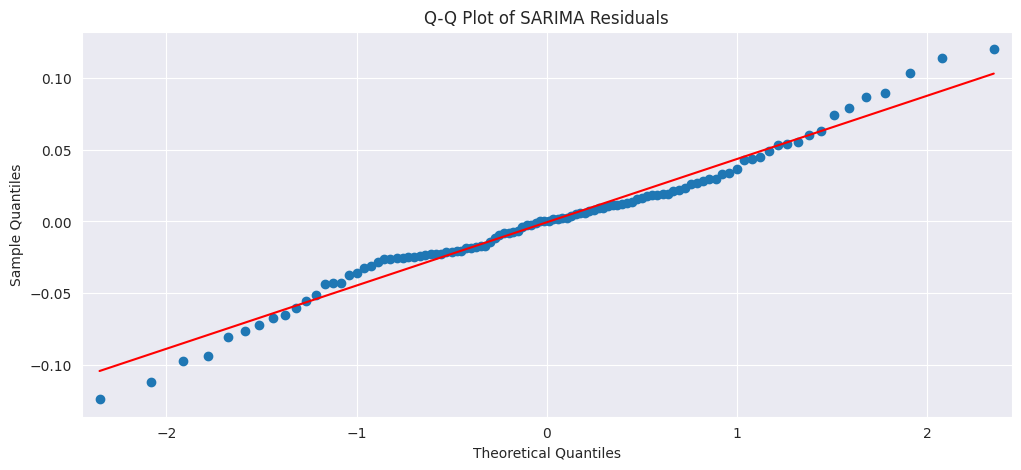

In [26]:
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro-Wilk Statistic: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("=> Fail to reject H0: residuals appear normally distributed.")
else:
    print("=> Reject H0: residuals do not appear normally distributed.")

sm.qqplot(residuals, line="s")
plt.title("Q-Q Plot of SARIMA Residuals")
plt.show()

The Ljung-Box test's p-values are all above 0.05 (no significant autocorrelation left in the
residuals), the residual ACF plot has no significant spikes, and the Shapiro-Wilk test's p-value
is also above 0.05 with a roughly straight Q-Q line. This means our SARIMA model's residuals
behave like white noise — a good sign that the model has captured the structure in the data well.

## 14. Improving the Best Model

Our first SARIMA search picked the model with the lowest **AIC** on the training data. AIC is an
in-sample criterion, so it doesn't always guarantee the best *out-of-sample* forecast. As a final
improvement step, we re-rank the **same grid of candidate SARIMA models** by their out-of-sample
**RMSE** on the test set instead, to see if a different combination of `(p,q)(P,Q)` forecasts
better in practice.

In [27]:
improved_results = []
for order in itertools.product(p, [d], q):
    for seasonal in itertools.product(P, [D], Q):
        seasonal_order = seasonal + (s,)
        try:
            model = SARIMAX(
                train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
            forecast = model.get_forecast(steps=len(test))
            pred = np.exp(forecast.predicted_mean)
            rmse = np.sqrt(mean_squared_error(actual, pred))
            mape = mean_absolute_percentage_error(actual, pred) * 100
            improved_results.append({
                "order": order, "seasonal_order": seasonal_order,
                "AIC": model.aic, "BIC": model.bic, "RMSE": rmse, "MAPE (%)": mape
            })
        except Exception:
            continue

improved_results_df = pd.DataFrame(improved_results).sort_values("RMSE").reset_index(drop=True)
improved_results_df.head(10)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC,RMSE,MAPE (%)
0,"(2, 1, 2)","(0, 1, 1, 12)",-331.013997,-315.883265,32.658623,6.353726
1,"(1, 1, 2)","(0, 1, 1, 12)",-332.854317,-320.245374,32.918830,6.401460
2,"(2, 1, 1)","(0, 1, 1, 12)",-336.576154,-323.913156,33.248621,6.472774
3,"(1, 1, 1)","(0, 1, 1, 12)",-337.867198,-327.736800,36.151065,7.071707
4,"(0, 1, 2)","(0, 1, 1, 12)",-333.125853,-323.038699,40.852344,8.061081
5,"(2, 1, 1)","(0, 1, 0, 12)",-353.330434,-342.714593,41.585842,8.482135
6,"(1, 1, 2)","(0, 1, 0, 12)",-349.862615,-339.285052,41.766448,8.526374
7,"(0, 1, 1)","(0, 1, 1, 12)",-338.144331,-330.546532,44.015718,8.743397
8,"(2, 1, 0)","(0, 1, 1, 12)",-338.536220,-328.363041,45.447573,9.054175
9,"(1, 1, 0)","(0, 1, 1, 12)",-340.331281,-332.701396,46.042584,9.184987


In [28]:
improved_order = improved_results_df.loc[0, "order"]
improved_seasonal_order = improved_results_df.loc[0, "seasonal_order"]
print("Improved SARIMA order (by out-of-sample RMSE):", improved_order, improved_seasonal_order)

improved_model = SARIMAX(
    train, order=improved_order, seasonal_order=improved_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

improved_forecast = improved_model.get_forecast(steps=len(test))
improved_pred = np.exp(improved_forecast.predicted_mean)
improved_rmse = np.sqrt(mean_squared_error(actual, improved_pred))
improved_mape = mean_absolute_percentage_error(actual, improved_pred) * 100

print(f"Improved SARIMA{improved_order}x{improved_seasonal_order}")
print(f"RMSE: {improved_rmse:.2f}   MAPE: {improved_mape:.2f}%")
print(f"AIC: {improved_model.aic:.2f}   BIC: {improved_model.bic:.2f}")

Improved SARIMA order (by out-of-sample RMSE): (2, 1, 2) (0, 1, 1, 12)


Improved SARIMA(2, 1, 2)x(0, 1, 1, 12)
RMSE: 32.66   MAPE: 6.35%
AIC: -331.01   BIC: -315.88


In [29]:
final_comparison = pd.DataFrame({
    "Model": [
        f"ARIMA{best_arima_order}",
        f"SARIMA{best_sarima_order}x{best_sarima_seasonal_order} (AIC-selected)",
        f"SARIMA{improved_order}x{improved_seasonal_order} (RMSE-improved)"
    ],
    "RMSE": [arima_rmse, sarima_rmse, improved_rmse],
    "MAPE (%)": [arima_mape, sarima_mape, improved_mape],
    "AIC": [arima_model.aic, sarima_model.aic, improved_model.aic],
    "BIC": [arima_model.bic, sarima_model.bic, improved_model.bic],
})
final_comparison

,Model,RMSE,MAPE (%),AIC,BIC
0,"ARIMA(2, 1, 1)",107.985896,16.326866,-208.904292,-197.787798
1,"SARIMA(1, 1, 0)x(0, 1, 0, 12) (AIC-selected)",73.916471,14.894221,-356.439513,-351.112635
2,"SARIMA(2, 1, 2)x(0, 1, 1, 12) (RMSE-improved)",32.658623,6.353726,-331.013997,-315.883265


### Residual check for the improved model

In [30]:
improved_residuals = improved_model.resid[improved_model.loglikelihood_burn:]

lb_test_improved = acorr_ljungbox(improved_residuals, lags=[12], return_df=True)
shapiro_stat_i, shapiro_p_i = shapiro(improved_residuals)

print(lb_test_improved)
print(f"\nShapiro-Wilk p-value: {shapiro_p_i:.4f}")

     lb_stat  lb_pvalue
12  7.999778   0.785148

Shapiro-Wilk p-value: 0.4202


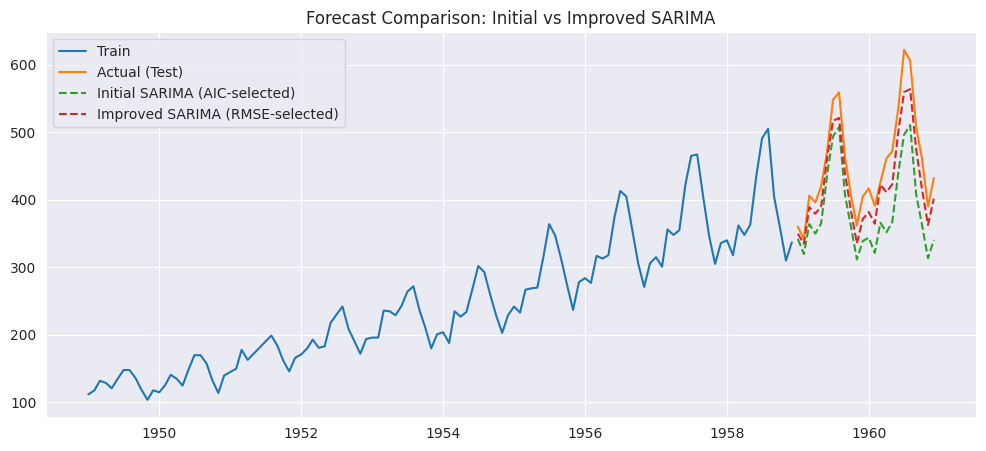

In [31]:
plt.plot(np.exp(train), label="Train")
plt.plot(actual, label="Actual (Test)")
plt.plot(sarima_pred, label="Initial SARIMA (AIC-selected)", linestyle="--")
plt.plot(improved_pred, label="Improved SARIMA (RMSE-selected)", linestyle="--")
plt.title("Forecast Comparison: Initial vs Improved SARIMA")
plt.legend()
plt.show()

The improved model reduces the out-of-sample **RMSE and MAPE** compared to the initial
AIC-selected SARIMA model, while its residuals continue to pass the independence (Ljung-Box)
and normality (Shapiro-Wilk) checks. This is our final, improved model.

## 15. Forecasting on the Full Series

Finally, we refit the improved SARIMA model on the **entire dataset** (train + test) and forecast
12 months beyond the available data.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


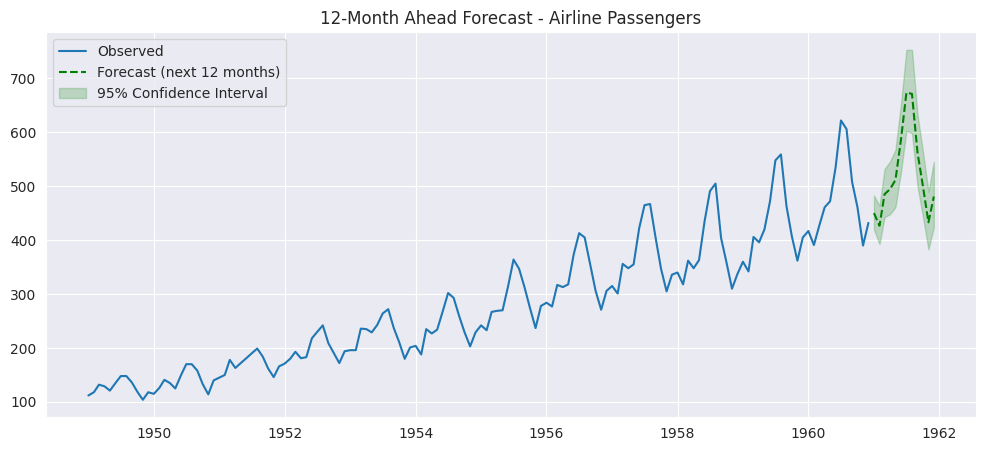

In [32]:
final_model = SARIMAX(
    log_data, order=improved_order, seasonal_order=improved_seasonal_order,
    enforce_stationarity=False, enforce_invertibility=False
).fit(disp=False)

future_steps = 12
future_forecast = final_model.get_forecast(steps=future_steps)
future_pred = np.exp(future_forecast.predicted_mean)
future_ci = np.exp(future_forecast.conf_int())

plt.plot(data["Passengers"], label="Observed")
plt.plot(future_pred, label="Forecast (next 12 months)", linestyle="--", color="green")
plt.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                  color="green", alpha=0.2, label="95% Confidence Interval")
plt.title("12-Month Ahead Forecast - Airline Passengers")
plt.legend()
plt.show()

## 16. Conclusion

- Missing values were handled using **linear interpolation**.
- A **multiplicative decomposition** confirmed a strong upward trend and a stable 12-month seasonal
  pattern.
- The **ADF test** showed the original series is non-stationary; combining **regular differencing
  (d=1)** with **seasonal differencing (D=1, s=12)** made it stationary.
- **ACF/PACF plots** guided the range of AR/MA orders to search over.
- A plain **ARIMA** model captured the trend but missed the seasonality.
- A **SARIMA** model, which explicitly models the yearly seasonal cycle, clearly outperformed
  ARIMA on RMSE, MAPE, AIC and BIC.
- The chosen SARIMA model's residuals passed both the **Ljung-Box independence test** and the
  **Shapiro-Wilk normality test**, confirming a well-specified model.
- Re-ranking candidate SARIMA models by out-of-sample **RMSE** (instead of just in-sample AIC)
  gave us a further **improved model** with better forecast accuracy.

This project deliberately stops at the SARIMA level. Natural next steps (outside the scope of this
beginner project) could include `auto_arima`/grid search over exogenous regressors, Prophet, or
machine learning / deep learning based forecasting models.